In [8]:
import pandas as pd

#load the dataset
df = pd.read_csv("Economy_data.csv", sep=";")
df.head()


,SeriesName,SeriesCode,CountryName,CountryCode,Year,Value
0,General government final consumption expenditu...,NE.CON.GOVT.ZS,Brazil,BRA,1970.0,11.324653
1,General government final consumption expenditu...,NE.CON.GOVT.ZS,China,CHN,1970.0,10.961783
2,General government final consumption expenditu...,NE.CON.GOVT.ZS,India,IND,1970.0,8.947244
3,General government final consumption expenditu...,NE.CON.GOVT.ZS,Russian Federation,RUS,1970.0,NaN
4,General government final consumption expenditu...,NE.CON.GOVT.ZS,South Africa,ZAF,1970.0,11.903314


In [9]:
#checking the columns
df.columns


Index(['SeriesName', 'SeriesCode', 'CountryName', 'CountryCode', 'Year',
       'Value'],
      dtype='object')

In [10]:
#filter bricks countries
brics = ['Brazil', 'Russian Federation', 'India', 'China', 'South Africa']

df_brics = df[df['CountryName'].isin(brics)].copy()
df_brics.head()


,SeriesName,SeriesCode,CountryName,CountryCode,Year,Value
0,General government final consumption expenditu...,NE.CON.GOVT.ZS,Brazil,BRA,1970.0,11.324653
1,General government final consumption expenditu...,NE.CON.GOVT.ZS,China,CHN,1970.0,10.961783
2,General government final consumption expenditu...,NE.CON.GOVT.ZS,India,IND,1970.0,8.947244
3,General government final consumption expenditu...,NE.CON.GOVT.ZS,Russian Federation,RUS,1970.0,NaN
4,General government final consumption expenditu...,NE.CON.GOVT.ZS,South Africa,ZAF,1970.0,11.903314


In [11]:
#fixing the datatype for stats
df_brics['Year'] = df_brics['Year'].astype(int)
df_brics['Value'] = pd.to_numeric(df_brics['Value'], errors='coerce')


In [12]:
df_brics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SeriesName   250 non-null    object 
 1   SeriesCode   250 non-null    object 
 2   CountryName  250 non-null    object 
 3   CountryCode  250 non-null    object 
 4   Year         250 non-null    int32  
 5   Value        231 non-null    float64
dtypes: float64(1), int32(1), object(4)
memory usage: 10.9+ KB


In [13]:
# Pivot the dataset
df_panel = df_brics.pivot_table(
    index=['CountryName', 'Year'],
    columns='SeriesName',
    values='Value'
).reset_index()

df_panel.head()


SeriesName,CountryName,Year,General government final consumption expenditure (% of GDP)
0,Brazil,1970,11.324653
1,Brazil,1971,11.022640
2,Brazil,1972,10.752926
3,Brazil,1973,10.445394
4,Brazil,1974,9.743238


In [14]:
#pick core variable
df_panel.columns


Index(['CountryName', 'Year',
       'General government final consumption expenditure (% of GDP)'],
      dtype='object', name='SeriesName')

In [16]:
#rename 

df_panel = df_panel.rename(columns={
    'General government final consumption expenditure (% of GDP)': 'gov_consumption'
})


In [17]:
#descriptive stats
df_panel.groupby('CountryName')['gov_consumption'].describe()


,count,mean,std,min,25%,50%,75%,max
CountryName,,,,,,,,
Brazil,50.0,15.682892,4.433095,8.284794,10.646667,18.498844,19.330485,20.927925
China,49.0,14.194945,1.499461,10.961783,13.188262,14.213949,15.238864,16.838430
India,50.0,10.543696,0.902525,8.407362,9.870270,10.489669,11.089898,12.175490
Russian Federation,32.0,18.012513,1.669099,13.857443,17.263811,17.950887,18.818457,21.067110
South Africa,50.0,17.454906,2.978406,11.111658,15.153463,18.547698,19.600433,21.295737


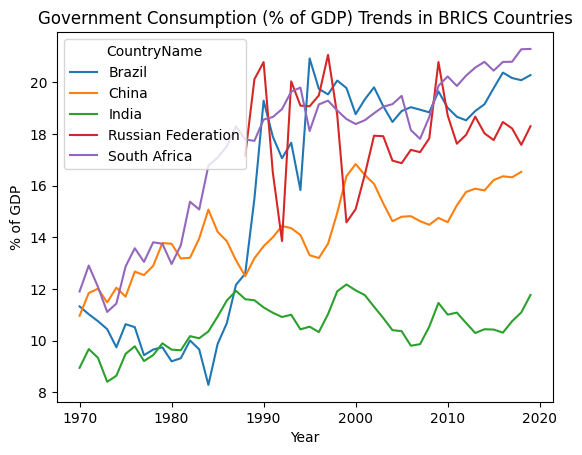

In [18]:
#Visualize trends over time
#This lets you see differences and trends visually

import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(data=df_panel, x='Year', y='gov_consumption', hue='CountryName')
plt.title("Government Consumption (% of GDP) Trends in BRICS Countries")
plt.ylabel("% of GDP")
plt.show()



In [19]:
#One-Way ANOVA
from scipy.stats import f_oneway

brazil = df_panel[df_panel['CountryName']=='Brazil']['gov_consumption'].dropna()
china = df_panel[df_panel['CountryName']=='China']['gov_consumption'].dropna()
india = df_panel[df_panel['CountryName']=='India']['gov_consumption'].dropna()
russia = df_panel[df_panel['CountryName']=='Russian Federation']['gov_consumption'].dropna()
south_africa = df_panel[df_panel['CountryName']=='South Africa']['gov_consumption'].dropna()

f_stat, p_val = f_oneway(brazil, china, india, russia, south_africa)
print("ANOVA F-statistic:", f_stat)
print("p-value:", p_val)


ANOVA F-statistic: 56.76166212932043
p-value: 4.273227781441054e-33


In [20]:
#Identify which countries differ using Tukey’s HSD post-hoc test
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df_panel['gov_consumption'],
                          groups=df_panel['CountryName'],
                          alpha=0.05)
print(tukey)


            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2       meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------
            Brazil              China  -1.4879 0.0494 -2.9733 -0.0026   True
            Brazil              India  -5.1392    0.0 -6.6171 -3.6613   True
            Brazil Russian Federation   2.3296 0.0015  0.6568  4.0025   True
            Brazil       South Africa    1.772 0.0099  0.2941  3.2499   True
             China              India  -3.6512    0.0 -5.1366 -2.1659   True
             China Russian Federation   3.8176    0.0  2.1381   5.497   True
             China       South Africa     3.26    0.0  1.7746  4.7453   True
             India Russian Federation   7.4688    0.0   5.796  9.1416   True
             India       South Africa   6.9112    0.0  5.4333  8.3891   True
Russian Federation       South Africa  -0.5576 0.8903 -2.2304  1.1152  False

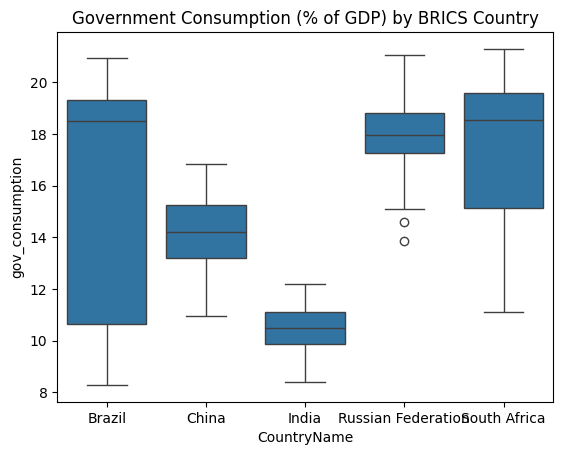

In [21]:
# Visualize differences
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df_panel, x='CountryName', y='gov_consumption')
plt.title("Government Consumption (% of GDP) by BRICS Country")
plt.show()


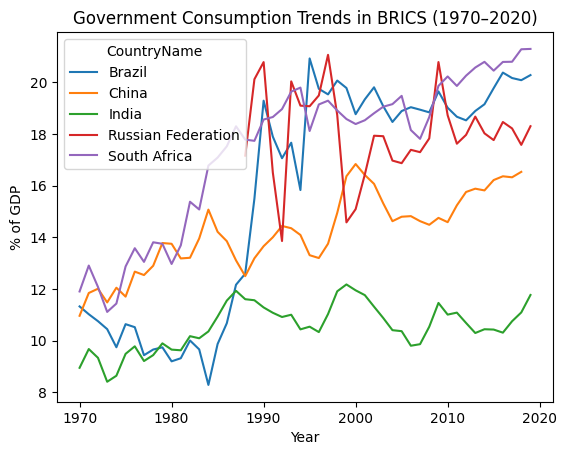

In [22]:
#Lineplot over time
sns.lineplot(data=df_panel, x='Year', y='gov_consumption', hue='CountryName')
plt.title("Government Consumption Trends in BRICS (1970–2020)")
plt.ylabel("% of GDP")
plt.show()
